# Customer Segmentation Analysis
### Behavioral & Demographic Clustering for an E-Commerce Platform

**Goal:** Segment customers using unsupervised machine learning (K-Means) based on demographic attributes and purchasing behavior, in order to enable targeted marketing, retention strategy, and personalized recommendations.

**Dataset:** 2,500 synthetic e-commerce customers with 16 demographic and behavioral features (purchase frequency, average order value, recency, discount usage, app engagement, satisfaction, etc.)

**Workflow:**
1. Data loading & quality checks
2. Exploratory Data Analysis (EDA)
3. Feature engineering (RFM-style behavioral metrics)
4. Preprocessing (encoding, scaling)
5. Determining optimal cluster count (Elbow method + Silhouette score)
6. K-Means clustering
7. Cluster profiling & business interpretation
8. Visualization of segments
9. Actionable business recommendations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
palette = ['#2E5266', '#6E8898', '#D97B29', '#9DAA6B', '#B24C4C']
sns.set_palette(palette)

pd.set_option('display.max_columns', 50)
%matplotlib inline


## 1. Load & Inspect Data

In [2]:
df = pd.read_csv('../data/ecommerce_customers.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (2500, 17)


,customer_id,age,gender,annual_income_inr,city_tier,membership_years,purchase_frequency_per_year,avg_order_value_inr,total_spend_inr,days_since_last_purchase,monthly_app_sessions,discount_usage_rate,cart_abandonment_rate,product_return_rate,preferred_category,primary_channel,satisfaction_score
0,CUST01448,43,Other,1726000.0,Tier 1,2.90,5.0,5235.02,26183.70,31.1,7.8,0.111,0.349,0.062,Books & Stationery,Mobile App,2.86
1,CUST01115,24,Male,877000.0,Tier 2,0.78,1.3,1170.86,1486.82,0.0,4.1,0.440,0.457,0.042,Fashion & Apparel,Mobile App,3.33
2,CUST01065,18,Female,462000.0,Tier 3,0.62,2.8,970.14,2717.94,10.5,5.3,0.000,0.402,0.103,Home & Kitchen,Mobile App,3.42
3,CUST02288,26,Female,832000.0,Tier 1,0.99,5.0,929.36,4641.52,17.2,27.5,0.740,0.425,0.093,Sports & Fitness,Mobile App,3.62
4,CUST01538,22,Female,1101000.0,Tier 1,1.80,3.8,2280.72,8743.20,150.6,0.0,0.135,0.418,0.157,Home & Kitchen,Website,4.08


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  2500 non-null   str    
 1   age                          2500 non-null   int64  
 2   gender                       2500 non-null   str    
 3   annual_income_inr            2500 non-null   float64
 4   city_tier                    2500 non-null   str    
 5   membership_years             2500 non-null   float64
 6   purchase_frequency_per_year  2500 non-null   float64
 7   avg_order_value_inr          2500 non-null   float64
 8   total_spend_inr              2500 non-null   float64
 9   days_since_last_purchase     2500 non-null   float64
 10  monthly_app_sessions         2500 non-null   float64
 11  discount_usage_rate          2500 non-null   float64
 12  cart_abandonment_rate        2500 non-null   float64
 13  product_return_rate          

In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,2500,2500,CUST01448,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,2500.0,NaN,NaN,NaN,33.0516,9.457225,18.0,26.0,32.0,39.0,68.0
gender,2500,3,Female,1241,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annual_income_inr,2500.0,NaN,NaN,NaN,971719.2,558578.903028,150000.0,547000.0,757000.0,1399250.0,2972000.0
city_tier,2500,3,Tier 1,1085,NaN,NaN,NaN,NaN,NaN,NaN,NaN
membership_years,2500.0,NaN,NaN,NaN,2.222072,1.621481,0.05,0.78,2.03,3.3225,8.16
purchase_frequency_per_year,2500.0,NaN,NaN,NaN,11.7926,10.155328,0.0,3.9,6.9,20.2,47.3
avg_order_value_inr,2500.0,NaN,NaN,NaN,2408.928124,1786.076886,150.0,1004.545,1700.57,3683.1375,8937.7
total_spend_inr,2500.0,NaN,NaN,NaN,29082.308024,38026.596157,0.0,6137.8575,13953.64,29061.9725,198202.95
days_since_last_purchase,2500.0,NaN,NaN,NaN,35.25112,36.749948,0.0,8.1,20.45,49.0,194.8


## 2. Data Quality Checks

`satisfaction_score` has a small amount of missing data (~3%), consistent with customers who never completed a post-purchase survey. We impute with the median to avoid dropping rows.


In [5]:
print("Missing values:\n", df.isna().sum()[df.isna().sum() > 0])
print(f"\nDuplicate customer_ids: {df['customer_id'].duplicated().sum()}")

df['satisfaction_score'] = df['satisfaction_score'].fillna(df['satisfaction_score'].median())


Missing values:
 satisfaction_score    75
dtype: int64

Duplicate customer_ids: 0


## 3. Exploratory Data Analysis

We look at the distribution of key behavioral and demographic variables before clustering, to understand the raw shape of the customer base.


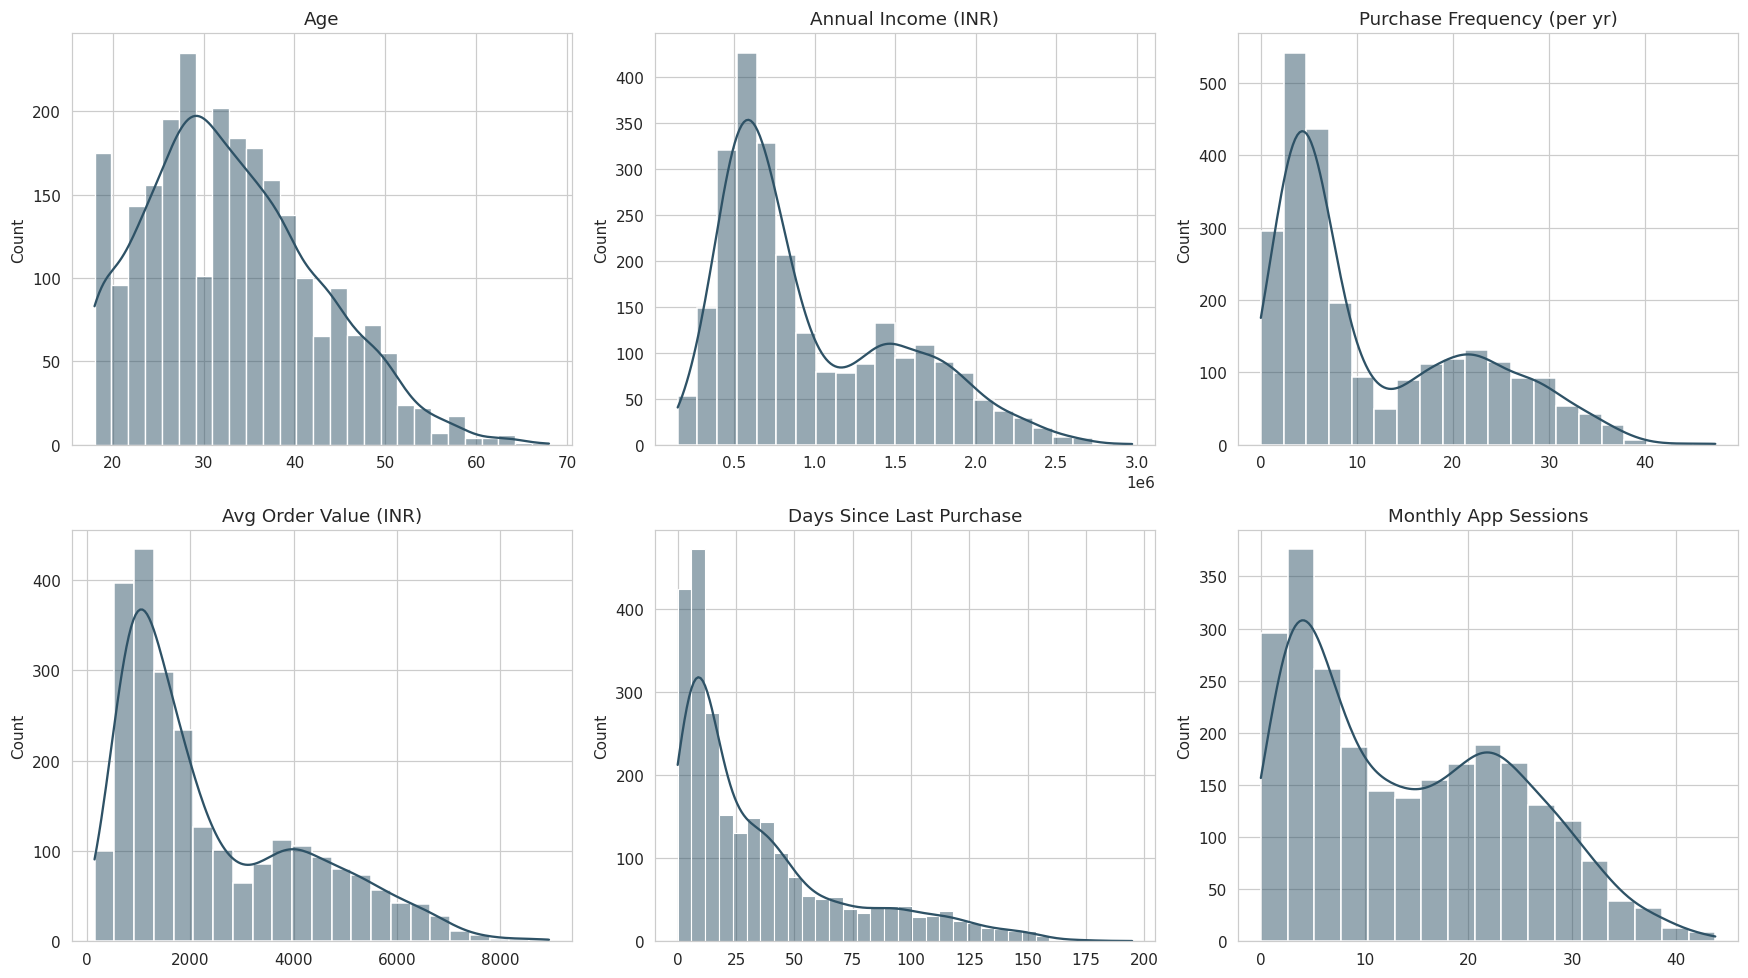

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
num_cols = ['age', 'annual_income_inr', 'purchase_frequency_per_year',
            'avg_order_value_inr', 'days_since_last_purchase', 'monthly_app_sessions']
titles = ['Age', 'Annual Income (INR)', 'Purchase Frequency (per yr)',
          'Avg Order Value (INR)', 'Days Since Last Purchase', 'Monthly App Sessions']

for ax, col, title in zip(axes.flat, num_cols, titles):
    sns.histplot(df[col], kde=True, ax=ax, color='#2E5266')
    ax.set_title(title)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('../images/eda_distributions.png', bbox_inches='tight')
plt.show()


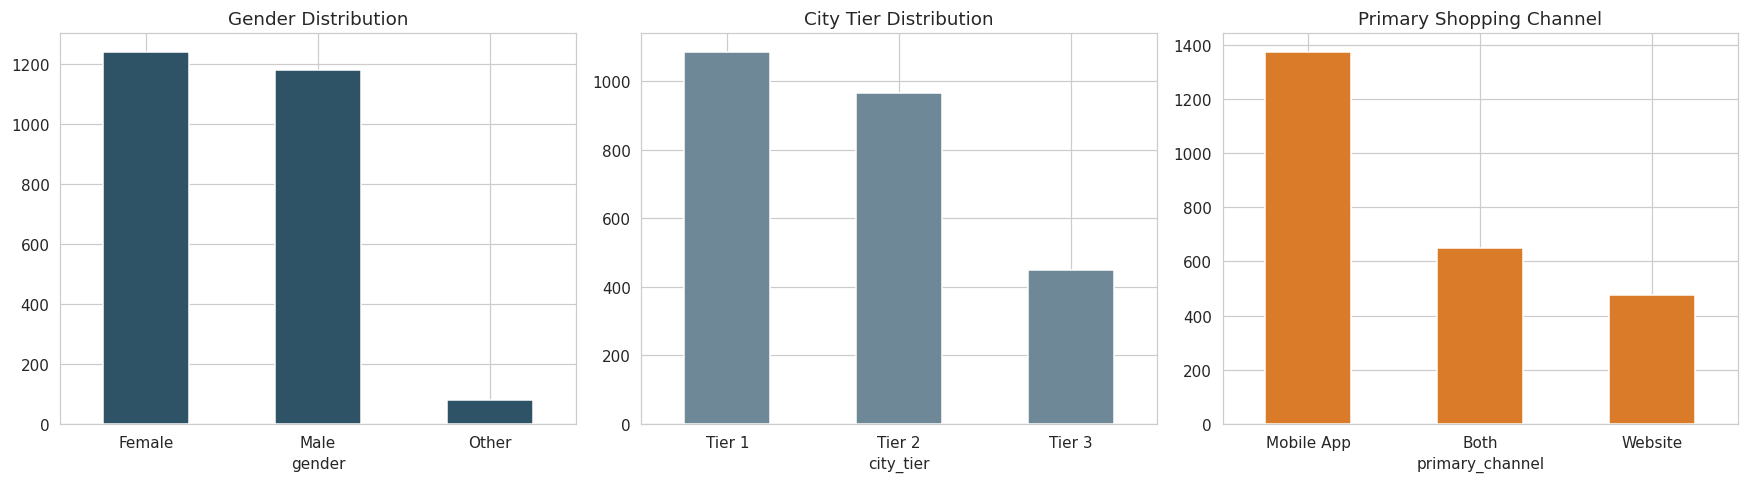

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

df['gender'].value_counts().plot(kind='bar', ax=axes[0], color='#2E5266')
axes[0].set_title('Gender Distribution')
axes[0].tick_params(axis='x', rotation=0)

df['city_tier'].value_counts().plot(kind='bar', ax=axes[1], color='#6E8898')
axes[1].set_title('City Tier Distribution')
axes[1].tick_params(axis='x', rotation=0)

df['primary_channel'].value_counts().plot(kind='bar', ax=axes[2], color='#D97B29')
axes[2].set_title('Primary Shopping Channel')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../images/eda_categorical.png', bbox_inches='tight')
plt.show()


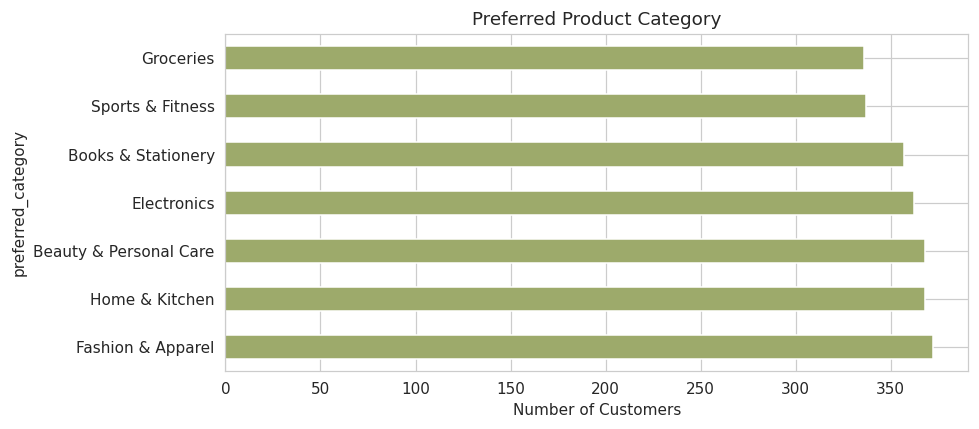

In [8]:
plt.figure(figsize=(9, 4))
df['preferred_category'].value_counts().plot(kind='barh', color='#9DAA6B')
plt.title('Preferred Product Category')
plt.xlabel('Number of Customers')
plt.tight_layout()
plt.savefig('../images/eda_category_pref.png', bbox_inches='tight')
plt.show()


### Correlation Check

Understanding which behavioral variables move together helps validate feature choices before clustering.


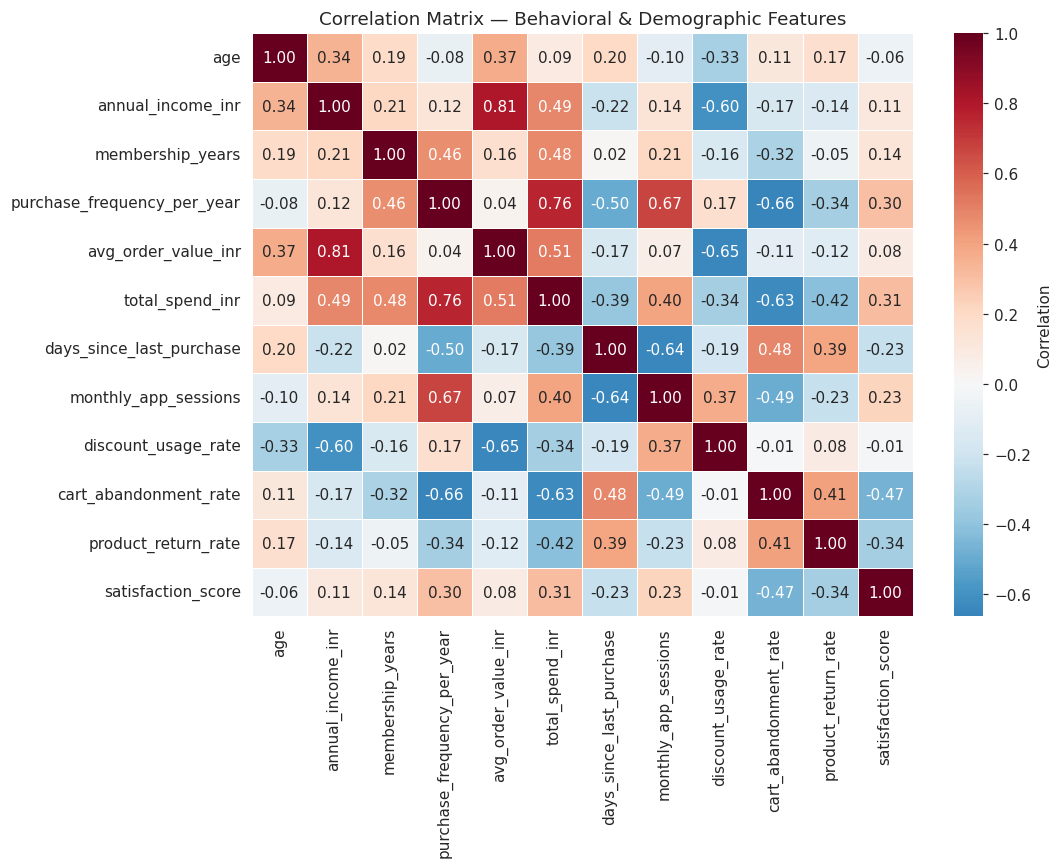

In [9]:
corr_cols = ['age', 'annual_income_inr', 'membership_years', 'purchase_frequency_per_year',
             'avg_order_value_inr', 'total_spend_inr', 'days_since_last_purchase',
             'monthly_app_sessions', 'discount_usage_rate', 'cart_abandonment_rate',
             'product_return_rate', 'satisfaction_score']

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix — Behavioral & Demographic Features')
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', bbox_inches='tight')
plt.show()


## 4. Feature Engineering — RFM-Style Behavioral Metrics

We build a classic **Recency–Frequency–Monetary (RFM)** foundation, extended with engagement and loyalty-risk signals:

- **Recency** → `days_since_last_purchase` (lower = more recently active)
- **Frequency** → `purchase_frequency_per_year`
- **Monetary** → `total_spend_inr`, `avg_order_value_inr`
- **Engagement** → `monthly_app_sessions`
- **Value-seeking behavior** → `discount_usage_rate`
- **Friction/risk signals** → `cart_abandonment_rate`, `product_return_rate`

We also compute an **RFM score** (quintile-based) as an interpretable business metric alongside the ML clusters.


In [10]:
# Quintile-based RFM scoring (1 = worst, 5 = best) — standard marketing technique
df['R_score'] = pd.qcut(df['days_since_last_purchase'], 5, labels=[5,4,3,2,1]).astype(int)
df['F_score'] = pd.qcut(df['purchase_frequency_per_year'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
df['M_score'] = pd.qcut(df['total_spend_inr'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
df['RFM_score'] = df['R_score'] + df['F_score'] + df['M_score']

df[['customer_id', 'days_since_last_purchase', 'purchase_frequency_per_year',
    'total_spend_inr', 'R_score', 'F_score', 'M_score', 'RFM_score']].head()


,customer_id,days_since_last_purchase,purchase_frequency_per_year,total_spend_inr,R_score,F_score,M_score,RFM_score
0,CUST01448,31.1,5.0,26183.70,3,2,4,9
1,CUST01115,0.0,1.3,1486.82,5,1,1,7
2,CUST01065,10.5,2.8,2717.94,4,1,1,6
3,CUST02288,17.2,5.0,4641.52,3,2,1,6
4,CUST01538,150.6,3.8,8743.20,1,2,2,5


## 5. Preprocessing for Clustering

K-Means is distance-based, so we:
1. Select the behavioral + demographic features that matter for segmentation
2. One-hot encode categorical variables (city tier, channel)
3. Standardize all features (zero mean, unit variance) so no single feature dominates due to scale (e.g. income in lakhs vs. rates between 0–1)


In [11]:
feature_cols_numeric = ['age', 'annual_income_inr', 'membership_years',
                         'purchase_frequency_per_year', 'avg_order_value_inr', 'total_spend_inr',
                         'days_since_last_purchase', 'monthly_app_sessions', 'discount_usage_rate',
                         'cart_abandonment_rate', 'product_return_rate', 'satisfaction_score']
feature_cols_categorical = ['city_tier', 'primary_channel']

X_numeric = df[feature_cols_numeric].copy()
X_categorical = pd.get_dummies(df[feature_cols_categorical], drop_first=True)

X = pd.concat([X_numeric, X_categorical], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()


,age,annual_income_inr,membership_years,purchase_frequency_per_year,avg_order_value_inr,total_spend_inr,days_since_last_purchase,monthly_app_sessions,discount_usage_rate,cart_abandonment_rate,product_return_rate,satisfaction_score,city_tier_Tier 2,city_tier_Tier 3,primary_channel_Mobile App,primary_channel_Website
0,1.052147,1.350627,0.418176,-0.669004,1.582607,-0.076241,-0.112978,-0.629124,-0.814292,-0.243922,-0.580090,-0.686268,-0.793553,-0.467886,0.905265,-0.484951
1,-0.957301,-0.169606,-0.889533,-1.033418,-0.693316,-0.725834,-0.959407,-0.985063,0.522590,0.311512,-1.062462,0.013878,1.260155,-0.467886,0.905265,-0.484951
2,-1.591863,-0.912711,-0.988228,-0.885683,-0.805719,-0.693453,-0.673636,-0.869623,-1.265337,0.028652,0.408771,0.147948,-0.793553,2.137271,0.905265,-0.484951
3,-0.745780,-0.250183,-0.759996,-0.669004,-0.828556,-0.642857,-0.491286,1.266012,1.741630,0.146939,0.167586,0.445883,-0.793553,-0.467886,0.905265,-0.484951
4,-1.168822,0.231492,-0.260352,-0.787193,-0.071796,-0.534972,3.139377,-1.379482,-0.716768,0.110939,1.711175,1.131132,-0.793553,-0.467886,-1.104649,2.062062


## 6. Choosing the Optimal Number of Clusters

We use two complementary methods:
- **Elbow Method** — inertia (within-cluster sum of squares) vs. k
- **Silhouette Score** — how well-separated and cohesive the clusters are (closer to 1 is better)


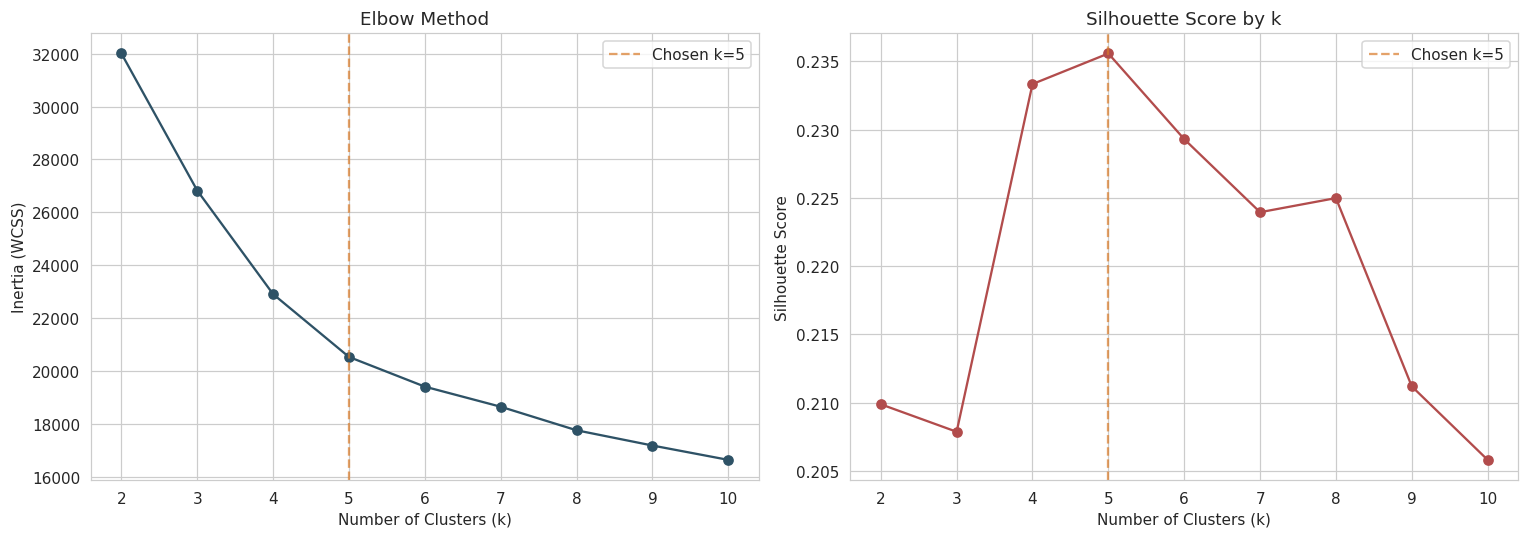

k=2: inertia=32004.1  silhouette=0.210  davies-bouldin=1.867
k=3: inertia=26825.7  silhouette=0.208  davies-bouldin=1.590
k=4: inertia=22912.4  silhouette=0.233  davies-bouldin=1.585
k=5: inertia=20539.5  silhouette=0.236  davies-bouldin=1.649
k=6: inertia=19417.5  silhouette=0.229  davies-bouldin=1.560
k=7: inertia=18658.7  silhouette=0.224  davies-bouldin=1.607
k=8: inertia=17769.1  silhouette=0.225  davies-bouldin=1.535
k=9: inertia=17193.3  silhouette=0.211  davies-bouldin=1.687
k=10: inertia=16651.0  silhouette=0.206  davies-bouldin=1.738


In [12]:
inertias = []
silhouettes = []
db_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker='o', color='#2E5266')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].axvline(5, color='#D97B29', linestyle='--', alpha=0.7, label='Chosen k=5')
axes[0].legend()

axes[1].plot(list(k_range), silhouettes, marker='o', color='#B24C4C')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(5, color='#D97B29', linestyle='--', alpha=0.7, label='Chosen k=5')
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/elbow_silhouette.png', bbox_inches='tight')
plt.show()

for k, inertia, sil, db in zip(k_range, inertias, silhouettes, db_scores):
    print(f"k={k}: inertia={inertia:.1f}  silhouette={sil:.3f}  davies-bouldin={db:.3f}")


**Interpretation:** The elbow flattens noticeably around **k=5**, and silhouette score is locally strong there too, while still keeping segments business-interpretable (too many clusters becomes hard to act on operationally). We proceed with **k=5**.


## 7. Fit Final K-Means Model

In [13]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df['cluster'])
db = davies_bouldin_score(X_scaled, df['cluster'])
print(f"Final Silhouette Score: {sil:.3f}")
print(f"Final Davies-Bouldin Index: {db:.3f}")
print(f"\nCluster sizes:\n{df['cluster'].value_counts().sort_index()}")


Final Silhouette Score: 0.236
Final Davies-Bouldin Index: 1.649

Cluster sizes:
cluster
0    446
1    576
2    482
3    570
4    426
Name: count, dtype: int64


## 8. Visualize Segments with PCA

We reduce the standardized feature space to 2 dimensions with PCA purely for visualization (clustering itself was done on the full feature space).


Explained variance ratio: [0.26200236 0.17401573]
Total variance captured in 2D: 43.6%


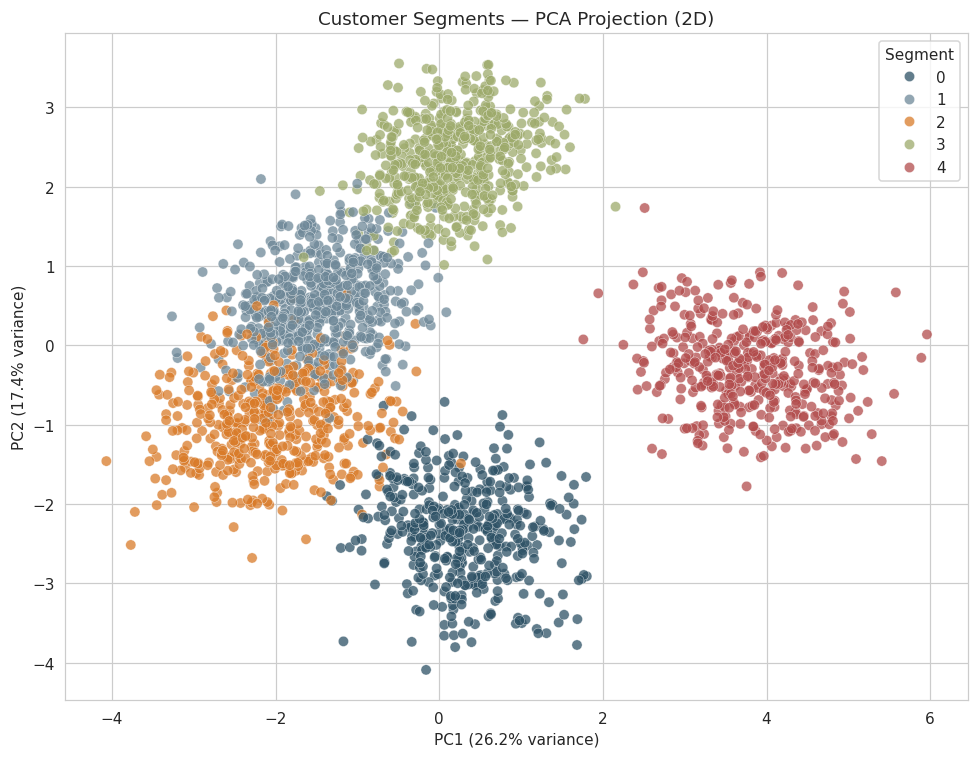

In [14]:
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled)
df['pca_1'] = pca_result[:, 0]
df['pca_2'] = pca_result[:, 1]

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance captured in 2D: {pca.explained_variance_ratio_.sum():.1%}")

plt.figure(figsize=(9, 7))
scatter = sns.scatterplot(data=df, x='pca_1', y='pca_2', hue='cluster',
                           palette=palette, s=45, alpha=0.75, edgecolor='white', linewidth=0.3)
plt.title('Customer Segments — PCA Projection (2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(title='Segment', loc='best')
plt.tight_layout()
plt.savefig('../images/pca_clusters.png', bbox_inches='tight')
plt.show()


## 9. Cluster Profiling

We now examine each cluster's average behavioral and demographic profile to translate math into marketing-ready personas.


In [15]:
profile_cols = ['age', 'annual_income_inr', 'membership_years', 'purchase_frequency_per_year',
                'avg_order_value_inr', 'total_spend_inr', 'days_since_last_purchase',
                'monthly_app_sessions', 'discount_usage_rate', 'cart_abandonment_rate',
                'product_return_rate', 'satisfaction_score', 'RFM_score']

cluster_profile = df.groupby('cluster')[profile_cols].mean().round(2)
cluster_profile['segment_size'] = df['cluster'].value_counts().sort_index()
cluster_profile['segment_%'] = (cluster_profile['segment_size'] / len(df) * 100).round(1)
cluster_profile


,age,annual_income_inr,membership_years,purchase_frequency_per_year,avg_order_value_inr,total_spend_inr,days_since_last_purchase,monthly_app_sessions,discount_usage_rate,cart_abandonment_rate,product_return_rate,satisfaction_score,RFM_score,segment_size,segment_%
cluster,,,,,,,,,,,,,,,
0,40.71,1788825.11,1.81,4.98,5221.77,26029.05,28.49,14.23,0.08,0.50,0.10,3.17,8.79,446,17.8
1,26.24,625527.78,0.56,3.37,1413.97,4752.88,35.82,6.00,0.31,0.46,0.07,3.27,5.66,576,23.0
2,38.44,685334.02,3.07,5.73,1606.63,9162.22,96.49,2.97,0.25,0.55,0.12,3.01,5.70,482,19.3
3,28.93,549203.51,2.13,18.86,865.29,16416.52,10.04,26.47,0.69,0.35,0.09,3.37,11.32,570,22.8
4,33.66,1473711.27,4.06,27.71,3782.53,104660.93,6.00,22.36,0.12,0.10,0.04,3.83,14.38,426,17.0


/tmp/ipykernel_626/249072900.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='cluster', y=col, ax=ax, palette=palette, errorbar=None)
/tmp/ipykernel_626/249072900.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='cluster', y=col, ax=ax, palette=palette, errorbar=None)
/tmp/ipykernel_626/249072900.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='cluster', y=col, ax=ax, palette=palette, errorbar=None)
/tmp/ipykernel_626/249072900.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is dep

/tmp/ipykernel_626/249072900.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='cluster', y=col, ax=ax, palette=palette, errorbar=None)


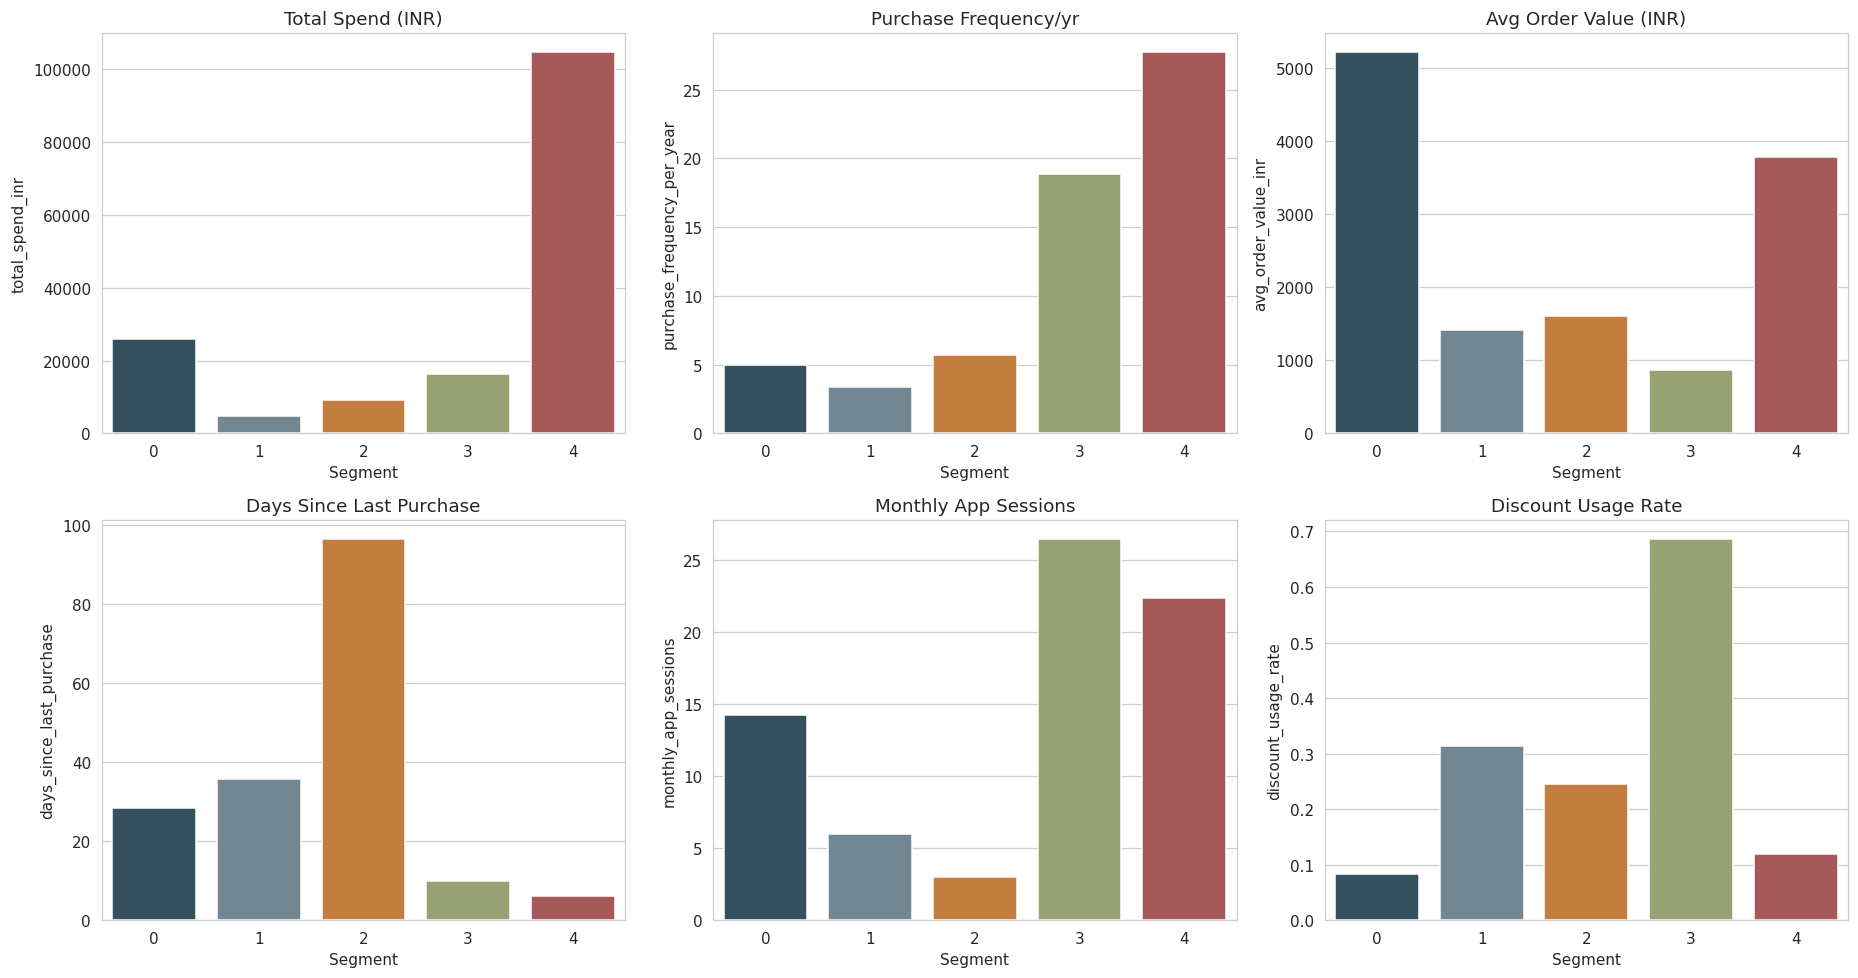

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
plot_cols = ['total_spend_inr', 'purchase_frequency_per_year', 'avg_order_value_inr',
             'days_since_last_purchase', 'monthly_app_sessions', 'discount_usage_rate']
plot_titles = ['Total Spend (INR)', 'Purchase Frequency/yr', 'Avg Order Value (INR)',
               'Days Since Last Purchase', 'Monthly App Sessions', 'Discount Usage Rate']

for ax, col, title in zip(axes.flat, plot_cols, plot_titles):
    sns.barplot(data=df, x='cluster', y=col, ax=ax, palette=palette, errorbar=None)
    ax.set_title(title)
    ax.set_xlabel('Segment')

plt.tight_layout()
plt.savefig('../images/cluster_profiles_bar.png', bbox_inches='tight')
plt.show()


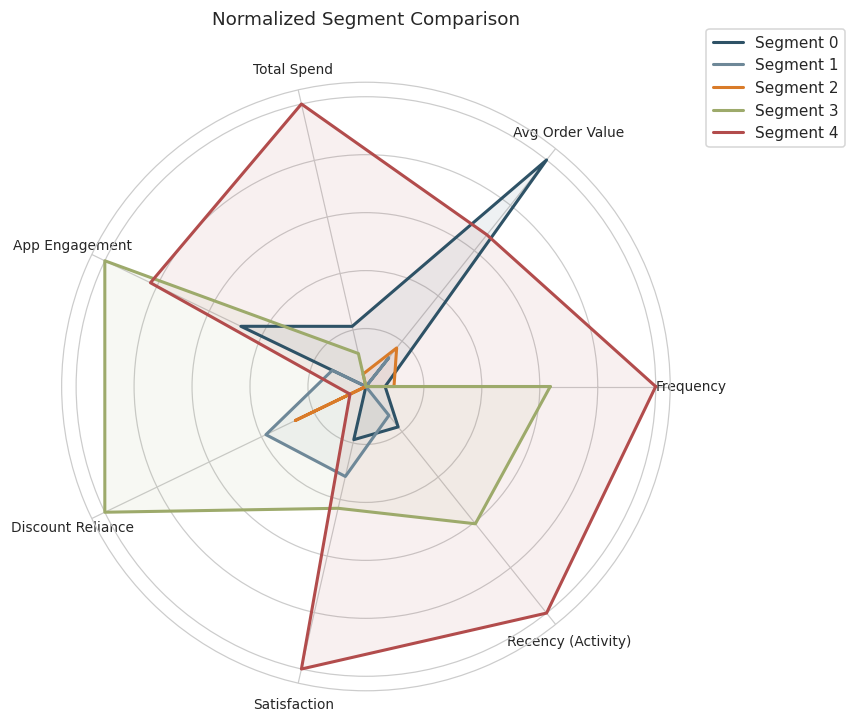

In [17]:
# Radar chart comparing normalized cluster profiles
from math import pi

radar_cols = ['purchase_frequency_per_year', 'avg_order_value_inr', 'total_spend_inr',
              'monthly_app_sessions', 'discount_usage_rate', 'satisfaction_score']
radar_labels = ['Frequency', 'Avg Order Value', 'Total Spend', 'App Engagement', 'Discount Reliance', 'Satisfaction']

radar_data = df.groupby('cluster')[radar_cols].mean()
# recency is 'lower is better' so invert it into a 'recency score' for the radar
radar_data['recency_score'] = 1 / (df.groupby('cluster')['days_since_last_purchase'].mean() + 1)
radar_cols_final = radar_cols + ['recency_score']
radar_labels_final = radar_labels + ['Recency (Activity)']

radar_norm = (radar_data[radar_cols_final] - radar_data[radar_cols_final].min()) / \
             (radar_data[radar_cols_final].max() - radar_data[radar_cols_final].min())

angles = [n / float(len(radar_cols_final)) * 2 * pi for n in range(len(radar_cols_final))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for i in radar_norm.index:
    values = radar_norm.loc[i].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f'Segment {i}', color=palette[i % len(palette)])
    ax.fill(angles, values, alpha=0.08, color=palette[i % len(palette)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels_final, size=9)
ax.set_yticklabels([])
plt.title('Normalized Segment Comparison', y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('../images/radar_comparison.png', bbox_inches='tight')
plt.show()


## 10. Naming the Segments

Based on the cluster profiles above, we assign business-friendly persona names.


In [18]:
# Greedy, rank-based persona assignment: at each step, assign the most distinguishing
# label to whichever *remaining* cluster is the strongest match for it. This avoids
# arbitrary median-split collisions and guarantees each cluster gets a unique persona.
remaining = list(cluster_profile.index)
persona_map = {}

# 1) The cluster with the highest recency (longest since last purchase) is At-Risk
c = cluster_profile.loc[remaining, 'days_since_last_purchase'].idxmax()
persona_map[c] = 'At-Risk / Churn-Prone'
remaining.remove(c)

# 2) Of what's left, highest total spend => Premium Loyalists
c = cluster_profile.loc[remaining, 'total_spend_inr'].idxmax()
persona_map[c] = 'Premium Loyalists'
remaining.remove(c)

# 3) Of what's left, highest discount reliance + frequency => Frequent Bargain Hunters
c = cluster_profile.loc[remaining, 'discount_usage_rate'].idxmax()
persona_map[c] = 'Frequent Bargain Hunters'
remaining.remove(c)

# 4) Of what's left, highest average order value => Premium Browsers
c = cluster_profile.loc[remaining, 'avg_order_value_inr'].idxmax()
persona_map[c] = 'Premium Browsers'
remaining.remove(c)

# 5) Whatever's left => New & Occasional Shoppers
for c in remaining:
    persona_map[c] = 'New & Occasional Shoppers'

df['persona'] = df['cluster'].map(persona_map)
print(persona_map)
df[['customer_id', 'cluster', 'persona']].head(10)


{np.int32(2): 'At-Risk / Churn-Prone', np.int32(4): 'Premium Loyalists', np.int32(3): 'Frequent Bargain Hunters', np.int32(0): 'Premium Browsers', 1: 'New & Occasional Shoppers'}


,customer_id,cluster,persona
0,CUST01448,0,Premium Browsers
1,CUST01115,1,New & Occasional Shoppers
2,CUST01065,1,New & Occasional Shoppers
3,CUST02288,3,Frequent Bargain Hunters
4,CUST01538,2,At-Risk / Churn-Prone
5,CUST00669,3,Frequent Bargain Hunters
6,CUST01584,1,New & Occasional Shoppers
7,CUST02405,2,At-Risk / Churn-Prone
8,CUST00498,4,Premium Loyalists
9,CUST02481,3,Frequent Bargain Hunters


In [19]:
persona_summary = df.groupby('persona')[profile_cols].mean().round(2)
persona_summary['count'] = df['persona'].value_counts()
persona_summary['% of customers'] = (persona_summary['count'] / len(df) * 100).round(1)
persona_summary.sort_values('total_spend_inr', ascending=False)


,age,annual_income_inr,membership_years,purchase_frequency_per_year,avg_order_value_inr,total_spend_inr,days_since_last_purchase,monthly_app_sessions,discount_usage_rate,cart_abandonment_rate,product_return_rate,satisfaction_score,RFM_score,count,% of customers
persona,,,,,,,,,,,,,,,
Premium Loyalists,33.66,1473711.27,4.06,27.71,3782.53,104660.93,6.00,22.36,0.12,0.10,0.04,3.83,14.38,426,17.0
Premium Browsers,40.71,1788825.11,1.81,4.98,5221.77,26029.05,28.49,14.23,0.08,0.50,0.10,3.17,8.79,446,17.8
Frequent Bargain Hunters,28.93,549203.51,2.13,18.86,865.29,16416.52,10.04,26.47,0.69,0.35,0.09,3.37,11.32,570,22.8
At-Risk / Churn-Prone,38.44,685334.02,3.07,5.73,1606.63,9162.22,96.49,2.97,0.25,0.55,0.12,3.01,5.70,482,19.3
New & Occasional Shoppers,26.24,625527.78,0.56,3.37,1413.97,4752.88,35.82,6.00,0.31,0.46,0.07,3.27,5.66,576,23.0


## 11. Segment Value Contribution

Which segments drive the most revenue vs. headcount? This is the single most useful chart for a marketing/business stakeholder.


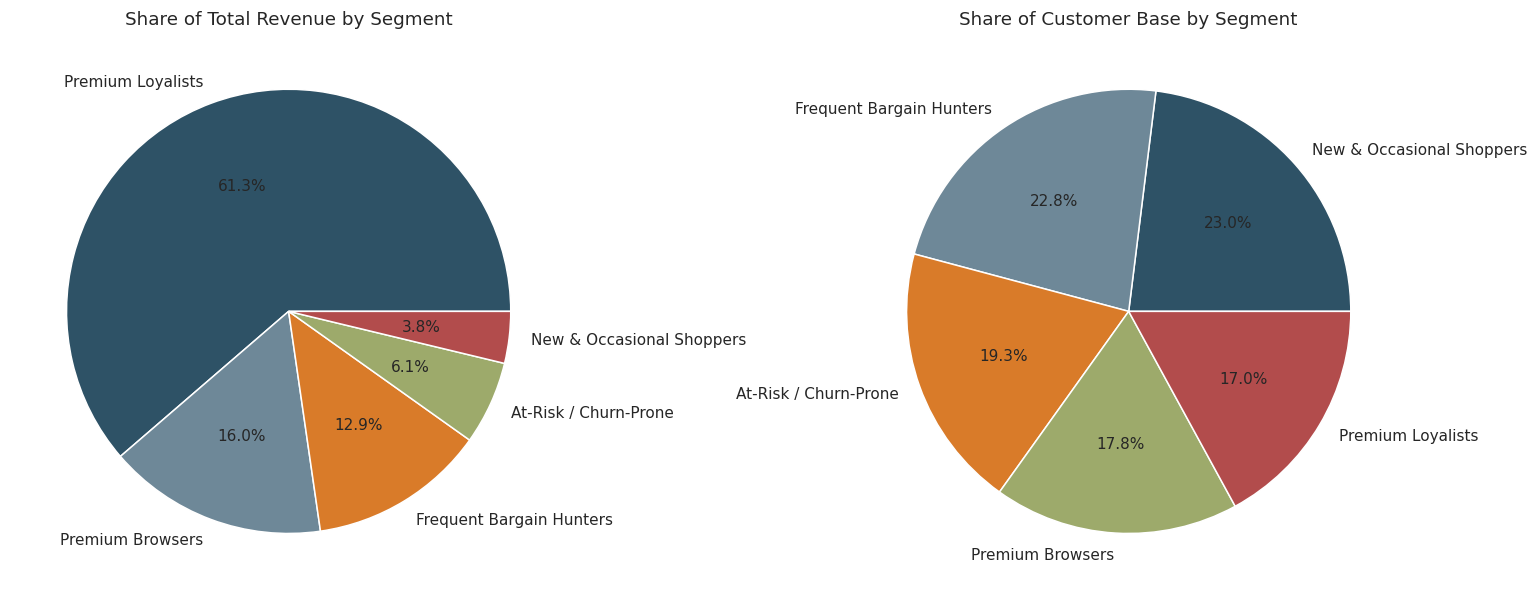

Revenue concentration check:
  Premium Loyalists: 17.0% of customers → 61.3% of revenue (index: 3.60x)
  Premium Browsers: 17.8% of customers → 16.0% of revenue (index: 0.90x)
  Frequent Bargain Hunters: 22.8% of customers → 12.9% of revenue (index: 0.56x)
  At-Risk / Churn-Prone: 19.3% of customers → 6.1% of revenue (index: 0.32x)
  New & Occasional Shoppers: 23.0% of customers → 3.8% of revenue (index: 0.16x)


In [20]:
revenue_share = df.groupby('persona')['total_spend_inr'].sum().sort_values(ascending=False)
customer_share = df['persona'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(revenue_share, labels=revenue_share.index, autopct='%1.1f%%',
            colors=palette, wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Share of Total Revenue by Segment')

axes[1].pie(customer_share, labels=customer_share.index, autopct='%1.1f%%',
            colors=palette, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Share of Customer Base by Segment')

plt.tight_layout()
plt.savefig('../images/revenue_vs_headcount.png', bbox_inches='tight')
plt.show()

print("Revenue concentration check:")
for persona in revenue_share.index:
    rev_pct = revenue_share[persona] / revenue_share.sum() * 100
    cust_pct = customer_share[persona] / customer_share.sum() * 100
    print(f"  {persona}: {cust_pct:.1f}% of customers → {rev_pct:.1f}% of revenue (index: {rev_pct/cust_pct:.2f}x)")


## 12. Category Preferences by Segment

Understanding what each segment likes to buy supports targeted product recommendations and campaign creative.


<Figure size 1320x660 with 0 Axes>

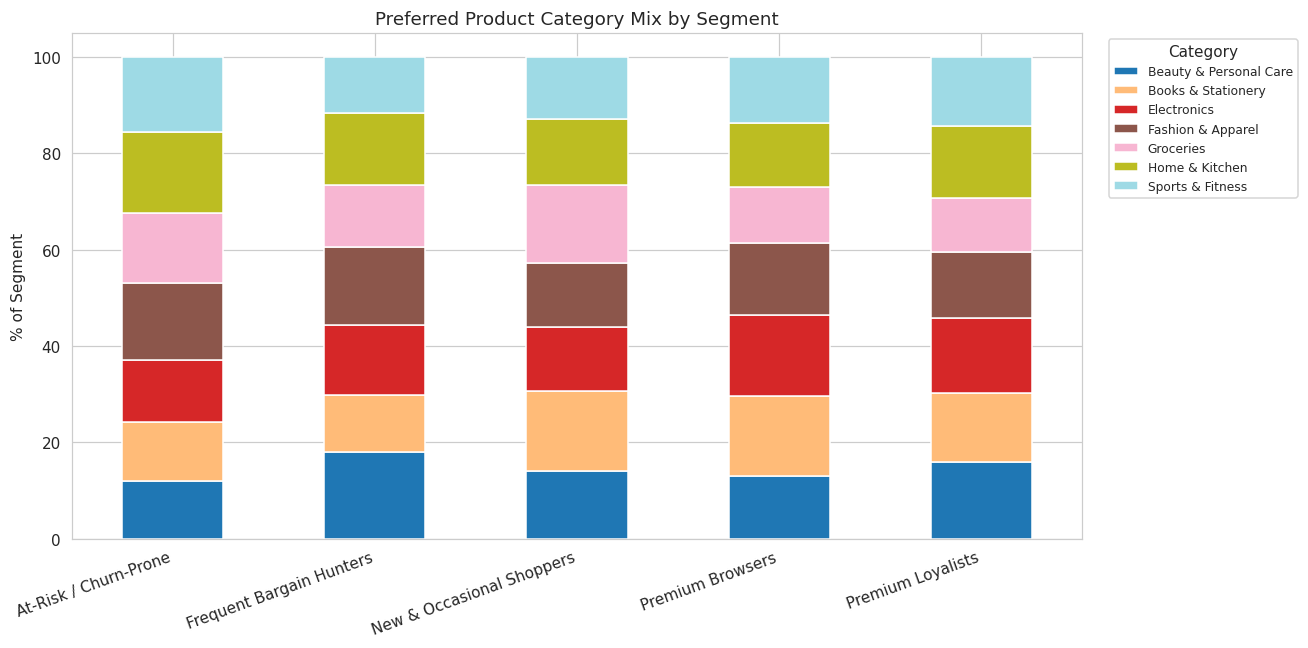

In [21]:
category_by_segment = pd.crosstab(df['persona'], df['preferred_category'], normalize='index') * 100

plt.figure(figsize=(12, 6))
category_by_segment.plot(kind='bar', stacked=True, colormap='tab20', figsize=(12, 6))
plt.title('Preferred Product Category Mix by Segment')
plt.ylabel('% of Segment')
plt.xlabel('')
plt.xticks(rotation=20, ha='right')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Category', fontsize=8)
plt.tight_layout()
plt.savefig('../images/category_by_segment.png', bbox_inches='tight')
plt.show()


## 13. Export Segmented Dataset

We save the final labeled dataset (with cluster ID and persona name) for use in the Power BI / dashboard layer and for downstream marketing systems (CRM, email platform, ad audience uploads).


In [22]:
export_cols = ['customer_id', 'age', 'gender', 'annual_income_inr', 'city_tier',
               'membership_years', 'purchase_frequency_per_year', 'avg_order_value_inr',
               'total_spend_inr', 'days_since_last_purchase', 'monthly_app_sessions',
               'discount_usage_rate', 'cart_abandonment_rate', 'product_return_rate',
               'preferred_category', 'primary_channel', 'satisfaction_score',
               'RFM_score', 'cluster', 'persona']

df[export_cols].to_csv('../data/customers_segmented.csv', index=False)
persona_summary.to_csv('../data/segment_profiles_summary.csv')
print("Exported: customers_segmented.csv, segment_profiles_summary.csv")
df[export_cols].head()


Exported: customers_segmented.csv, segment_profiles_summary.csv


,customer_id,age,gender,annual_income_inr,city_tier,membership_years,purchase_frequency_per_year,avg_order_value_inr,total_spend_inr,days_since_last_purchase,monthly_app_sessions,discount_usage_rate,cart_abandonment_rate,product_return_rate,preferred_category,primary_channel,satisfaction_score,RFM_score,cluster,persona
0,CUST01448,43,Other,1726000.0,Tier 1,2.90,5.0,5235.02,26183.70,31.1,7.8,0.111,0.349,0.062,Books & Stationery,Mobile App,2.86,9,0,Premium Browsers
1,CUST01115,24,Male,877000.0,Tier 2,0.78,1.3,1170.86,1486.82,0.0,4.1,0.440,0.457,0.042,Fashion & Apparel,Mobile App,3.33,7,1,New & Occasional Shoppers
2,CUST01065,18,Female,462000.0,Tier 3,0.62,2.8,970.14,2717.94,10.5,5.3,0.000,0.402,0.103,Home & Kitchen,Mobile App,3.42,6,1,New & Occasional Shoppers
3,CUST02288,26,Female,832000.0,Tier 1,0.99,5.0,929.36,4641.52,17.2,27.5,0.740,0.425,0.093,Sports & Fitness,Mobile App,3.62,6,3,Frequent Bargain Hunters
4,CUST01538,22,Female,1101000.0,Tier 1,1.80,3.8,2280.72,8743.20,150.6,0.0,0.135,0.418,0.157,Home & Kitchen,Website,4.08,5,2,At-Risk / Churn-Prone


## 14. Business Recommendations Summary

| Segment | Profile | Recommended Strategy |
|---|---|---|
| **Premium Loyalists** | High spend, frequent, recent, low discount reliance | VIP tiering, early access to new drops, referral incentives — protect and reward, avoid over-discounting |
| **Frequent Bargain Hunters** | High frequency, low AOV, heavy discount usage | Bundle offers, loyalty points on full-price items to nudge margin, cross-sell to raise basket size |
| **New & Occasional Shoppers** | Low tenure, low frequency, still exploring | Onboarding journeys, category-discovery nudges, second-purchase incentive within 30 days |
| **At-Risk / Churn-Prone** | Long recency, falling engagement | Win-back campaigns, personalized reactivation discounts, feedback surveys to diagnose drop-off |
| **Premium Browsers** | High income, high AOV, low frequency | Curated/editorial content, high-touch personalization, retarget with premium new arrivals rather than blanket discounts |

**Key insight:** Revenue concentration is not proportional to headcount — a small high-value segment can contribute disproportionately to revenue (see Section 11), which should guide where retention and CRM budget is spent first.

**Next steps for production use:**
- Refresh clustering monthly/quarterly as behavior shifts (avoid static personas)
- A/B test segment-specific campaigns and measure lift over a control group
- Feed `cluster`/`persona` into the CRM and ad platforms as a custom audience field
- Track segment migration over time (e.g. Bargain Hunter → Premium Loyalist) as a loyalty-program KPI
